# 01 — Exploratory Data Analysis
**Delhi NCR AQI Dataset (2020–2025)**

Before building any model, I explored the dataset to understand its structure,
identify patterns, and decide which features are worth keeping.


## 1. Load & inspect

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

df = pd.read_csv("../data/delhi_ncr_aqi_dataset.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Shape: (201664, 25)
Columns: ['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi', 'aqi_category']


In [2]:
df.head(3)

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe


## 2. Missing values
Checked for nulls — none found. No imputation needed.

In [3]:
print("Missing values:")
print(df.isnull().sum().sum())

Missing values:
0


## 3. AQI distribution
The target variable is right-skewed — most readings fall in the Moderate–Severe range,
which reflects Delhi's persistently poor air quality.

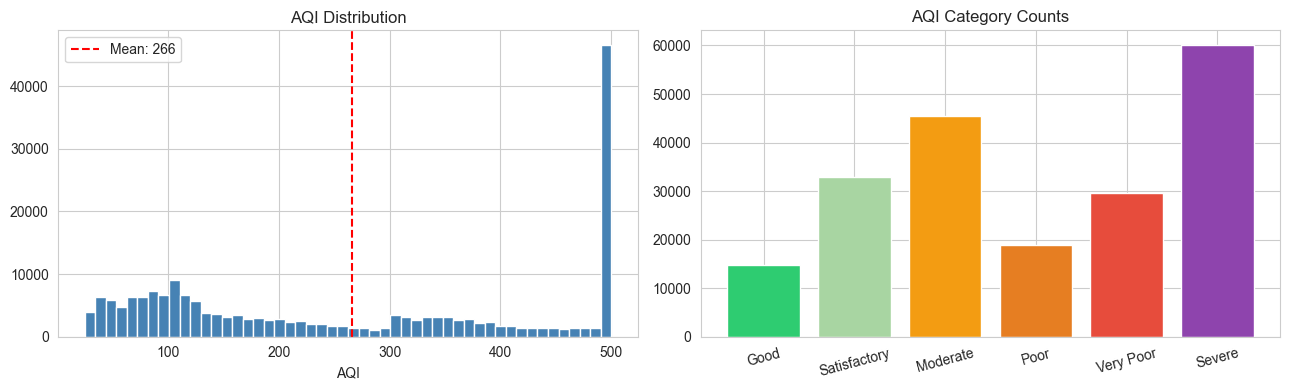

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['aqi'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(df['aqi'].mean(), color='red', linestyle='--', label=f"Mean: {df['aqi'].mean():.0f}")
axes[0].set_title("AQI Distribution")
axes[0].set_xlabel("AQI"); axes[0].legend()

cat_order = ['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']
colors = ['#2ecc71','#a8d5a2','#f39c12','#e67e22','#e74c3c','#8e44ad']
counts = df['aqi_category'].value_counts().reindex(cat_order)
axes[1].bar(counts.index, counts.values, color=colors, edgecolor='white')
axes[1].set_title("AQI Category Counts")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout(); plt.show()

## 4. Seasonal & monthly patterns
AQI is strongly seasonal — winter is the worst (crop burning + cold air trapping pollutants),
monsoon is the best (rain cleans the air).

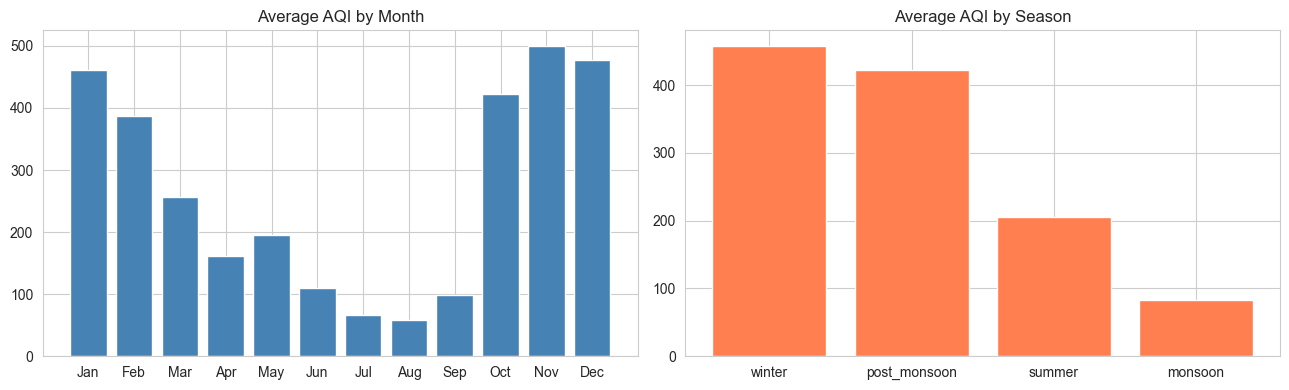

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

monthly = df.groupby('month')['aqi'].mean()
axes[0].bar(range(1,13), monthly.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(1,13))
axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0].set_title("Average AQI by Month")

season_aqi = df.groupby('season')['aqi'].mean().sort_values(ascending=False)
axes[1].bar(season_aqi.index, season_aqi.values, color='coral', edgecolor='white')
axes[1].set_title("Average AQI by Season")

plt.tight_layout(); plt.show()

## 5. City comparison
All 5 NCR cities show similar AQI patterns, though Delhi stations show slightly higher
median values due to higher traffic and industrial density.

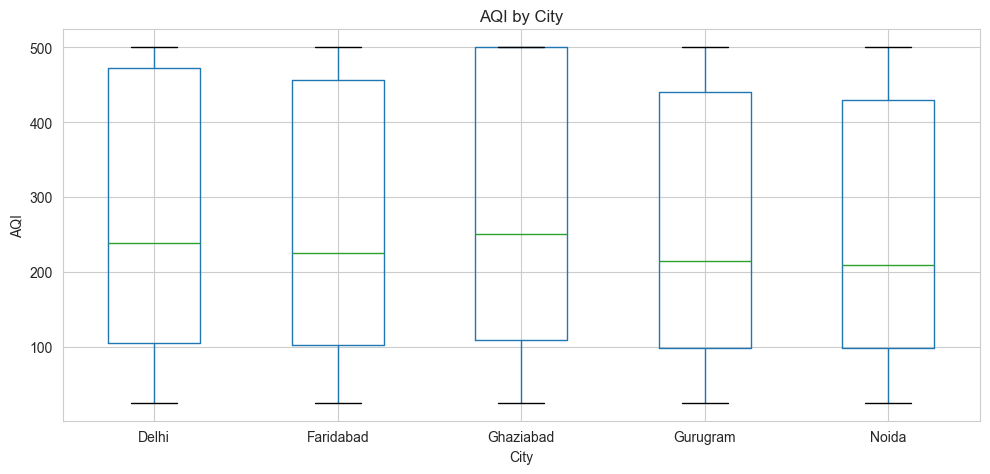

In [6]:
df.boxplot(column='aqi', by='city', figsize=(10,5))
plt.title("AQI by City"); plt.suptitle("")
plt.xlabel("City"); plt.ylabel("AQI")
plt.tight_layout(); plt.show()

## 6. Correlation with AQI
Pollutants (PM2.5, PM10, CO) correlate strongly and positively with AQI.
Weather features (visibility, wind speed, temperature) correlate negatively —
clean, windy, warm conditions mean lower AQI.

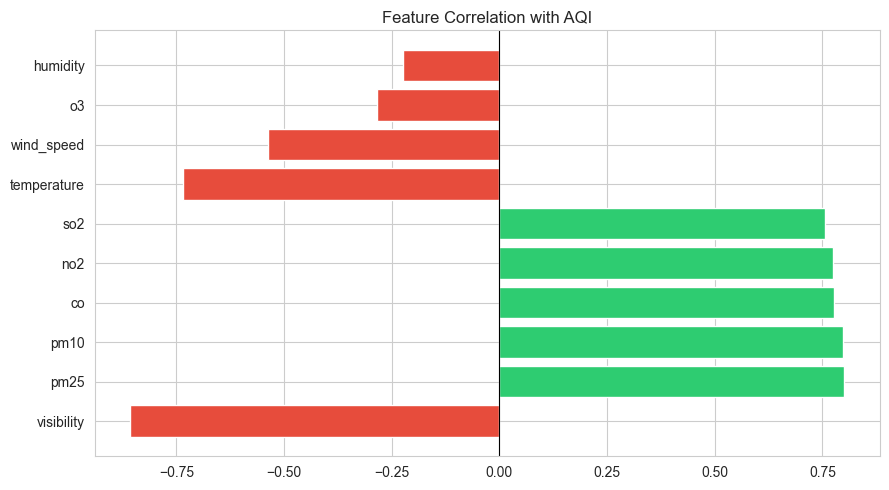

In [7]:
num_cols = ['pm25','pm10','no2','so2','co','o3',
            'temperature','humidity','wind_speed','visibility','aqi']
corr = df[num_cols].corr()['aqi'].drop('aqi').sort_values(key=abs, ascending=False)

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr.values]
plt.figure(figsize=(9,5))
plt.barh(corr.index, corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Correlation with AQI")
plt.tight_layout(); plt.show()

## 7. Key findings
- **Season is the dominant driver** of AQI in Delhi NCR
- **PM2.5 and PM10** are the strongest positively correlated features
- **Visibility and wind speed** are the strongest negatively correlated features
- **Zero missing values** — no imputation needed
- Dataset contains **201,664 hourly readings** across 5 cities from 2020–2025

These findings directly informed feature selection in the preprocessing phase.
